In [1]:
import sys

!{sys.executable} -m pip install scikit-network

In [22]:
import numpy as np

from IPython.display import SVG
from sknetwork.data import painters
from sknetwork.visualization import svg_graph, svg_digraph

graph = painters(metadata=True)
adjacency = graph.adjacency
names = graph.names
position = graph.position

In [23]:
from sknetwork.ranking import PageRank

pagerank = PageRank()
scores = pagerank.fit_transform(adjacency)
np.round(scores, 2)

array([0.06, 0.07, 0.12, 0.11, 0.11, 0.05, 0.02, 0.05, 0.04, 0.16, 0.05,
       0.05, 0.08, 0.02])

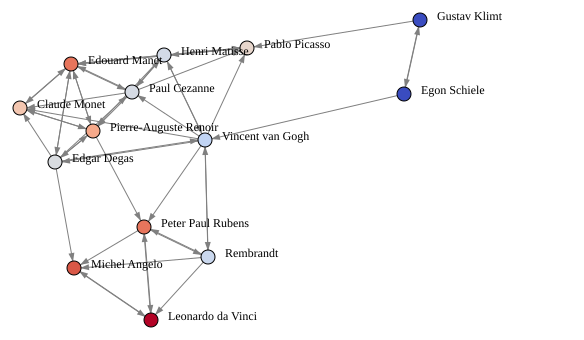

In [24]:
image = svg_digraph(adjacency, position, scores=np.log(scores), names=names)
SVG(image)

In [28]:
import networkx as nx

D= nx.DiGraph()
D.add_weighted_edges_from([('A','B',0.5),('A','C',0.5)])

nx.pagerank(D)

{'A': 0.25974050510584634, 'B': 0.3701297474470767, 'C': 0.3701297474470767}

In [29]:
D['A']['C']['weight']= 1

nx.pagerank(D)

{'A': 0.25974050510584634, 'B': 0.33333333333333326, 'C': 0.4069261615608201}

In [37]:
G= nx.DiGraph()

with open('graph.txt') as f:
    lines= f.readlines()
    
data= []
    
for line in lines:
    [parent, child, weight]= map(float, line.strip().split(','))
    data.append([parent, child, weight])
    
G.add_weighted_edges_from(data)

nx.pagerank(G)

{1.0: 0.2802877573557533,
 2.0: 0.15876468724856083,
 3.0: 0.13888170080462586,
 4.0: 0.10821930792439605,
 5.0: 0.18419866731369655,
 7.0: 0.06907737460022821,
 6.0: 0.06057050475273927}